In [3]:
%pip install astropy

   ---------------------------------------- 0.0/6.6 MB ? eta -:--:--
   ---- ----------------------------------- 0.7/6.6 MB 22.1 MB/s eta 0:00:01
   ------ --------------------------------- 1.0/6.6 MB 16.7 MB/s eta 0:00:01
   ------ --------------------------------- 1.0/6.6 MB 16.7 MB/s eta 0:00:01
   ------ --------------------------------- 1.0/6.6 MB 16.7 MB/s eta 0:00:01
   ------ --------------------------------- 1.0/6.6 MB 16.7 MB/s eta 0:00:01
   ------ --------------------------------- 1.0/6.6 MB 16.7 MB/s eta 0:00:01
   -------- ------------------------------- 1.4/6.6 MB 4.0 MB/s eta 0:00:02
   ------------ --------------------------- 2.1/6.6 MB 5.5 MB/s eta 0:00:01
   ----------------- ---------------------- 2.9/6.6 MB 6.7 MB/s eta 0:00:01
   ------------------- -------------------- 3.1/6.6 MB 6.9 MB/s eta 0:00:01
   ------------------------- -------------- 4.2/6.6 MB 7.9 MB/s eta 0:00:01
   ------------------------- -------------- 4.2/6.6 MB 7.9 MB/s eta 0:00:01
   ----------


[notice] A new release of pip is available: 24.0 -> 24.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
from astropy.io import fits

import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
import copy
import math
from statistics import mean
from os import listdir

In [2]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as meanse

In [4]:
image_path = r'./volumes_fits_29Mar2024/'
raw_data = fits.getdata(image_path + '017_Live_Edge_slices=50.fits')
normalized = raw_data/np.max(raw_data)

In [41]:
print(normalized)

[[[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  ...
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]]

 [[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  ...
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]]

 [[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.      

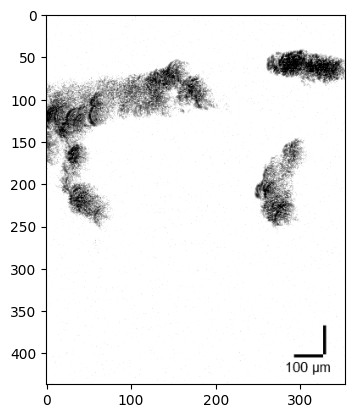

In [31]:
fig, ax = plt.subplots()
ax.imshow(raw_data[0,:,:], 'binary')

In [21]:
img0 = copy.deepcopy(normalized[0,:,:])
img25 = copy.deepcopy(normalized[25,:,:])
img49 = copy.deepcopy(normalized[49,:,:])

In [23]:
mse = meanse(img0, img25)
ssim1 = ssim(img0, img25, data_range=255)
print(mse)
print(ssim1)

0.02501542866346339
0.9975742537613456


In [3]:
image_path = r'./volumes_fits_29Mar2024/'
files = listdir(image_path)
ssim_list = []
for filename in files:
    raw_data = fits.getdata(image_path + filename)
    normalized = raw_data/np.max(raw_data)
    half = math.floor(normalized.shape[0] / 2)
    img1 = copy.deepcopy(normalized[0,:,:])
    img2 = copy.deepcopy(normalized[half,:,:])

    temp = ssim(img1, img2, data_range=1.0)
    ssim_list.append(temp)
print(ssim_list)
print(mean(ssim_list))

[0.19554233006282837, 0.4515398451216658, 0.447928236541101, 0.3977919632801471, 0.60026322204661, 0.5824187919355304, 0.6593684798067517, 0.4142514635114534, 0.6632455880113394, 0.5943321702618712, 0.6978362955883491, 0.456926202180001, 0.21379264635655668, 0.20234266506590393, 0.3147789822613698, 0.6194255462783255, 0.4551872422955312, 0.6835648862203351, 0.459940441462136, 0.7051778805688268, 0.053246059775124276, 0.4239582427746348, 0.10893251147374189, 0.551091839966363, 0.5924453940471656, 0.7124606728786034, 0.5856498877226235, 0.3963762449064985, 0.579402700460481, 0.8791664233096852, 0.575329296212837, 0.4420511596766178, 0.40388408560486483, 0.30965102825057156, 0.44465497648736285, 0.6033277444737564, 0.6188964350282932, 0.27037720389549463, 0.40908992089510454, 0.15836929163040128, 0.10959223366798737, 0.598745590642939, 0.42821379111338725, 0.7252313130983585, 0.25291070755494105, 0.6908544411787173, 0.3622644407541752, 0.7584214982445323, 0.5348612042857631, 0.68895205733

In [43]:
print(ssim_list)

[0.19554233006282837, 0.4515398451216658, 0.447928236541101, 0.3977919632801471, 0.60026322204661, 0.5824187919355304, 0.6593684798067517, 0.4142514635114534, 0.6632455880113394, 0.5943321702618712, 0.6978362955883491, 0.456926202180001, 0.21379264635655668, 0.20234266506590393, 0.3147789822613698, 0.6194255462783255, 0.4551872422955312, 0.6835648862203351, 0.459940441462136, 0.7051778805688268, 0.053246059775124276, 0.4239582427746348, 0.10893251147374189, 0.551091839966363, 0.5924453940471656, 0.7124606728786034, 0.5856498877226235, 0.3963762449064985, 0.579402700460481, 0.8791664233096852, 0.575329296212837, 0.4420511596766178, 0.40388408560486483, 0.30965102825057156, 0.44465497648736285, 0.6033277444737564, 0.6188964350282932, 0.27037720389549463, 0.40908992089510454, 0.15836929163040128, 0.10959223366798737, 0.598745590642939, 0.42821379111338725, 0.7252313130983585, 0.25291070755494105, 0.6908544411787173, 0.3622644407541752, 0.7584214982445323, 0.5348612042857631, 0.68895205733

# Thresholded image analysis

In [5]:
image_path = r'./volumes_fits_29Mar2024/'
files = listdir(image_path)
ssim_list = []
for filename in files:
    print(filename)
    raw_data = fits.getdata(image_path + filename)
    half = math.floor(raw_data.shape[0] / 2)
    print(half)
    img1 = copy.deepcopy(raw_data[0,:,:])
    img2 = copy.deepcopy(raw_data[half,:,:])
    val, img1_t = cv.threshold(img1,127,255,cv.THRESH_BINARY)
    val, img2_t = cv.threshold(img2,127,255,cv.THRESH_BINARY)

    temp = ssim(img1_t, img2_t, data_range=255)
    ssim_list.append(temp)
print(ssim_list)
print(mean(ssim_list))

008_Live_Edge_slices=50.fits
25
010_Live_Center_slices=50.fits
25
011_Dead_Edge_slices=50.fits
25
012_Dead_Edge_slices=50.fits
25
013_Dead_Edge_slices=50.fits
25
014_Dead_Edge_slices=50.fits
25
015_Decaying_Edge_slices=50.fits
25
016_Decaying_Edge_slices=50.fits
25
017_Live_Edge_slices=50.fits
6
020_Live_Edge_slices=50.fits
25
021_Decaying_Edge_slices=50.fits
25
022_Decaying_Edge_slices=50.fits
25
024_Live_Edge_slices=50.fits
25
026_Live_Edge_slices=50.fits
25
028_Live_Edge_slices=50.fits
25
030_Decaying_Edge_slices=50.fits
25
031_Decaying_Edge_slices=50.fits
25
032_Live_Edge_slices=50.fits
25
033_Decaying_Edge_slices=50.fits
25
035_Dead_Edge_slices=50.fits
17
036_Dead_Edge_slices=50.fits
25
037_Dead_Edge_slices=50.fits
25
038_Live_Edge_slices=50.fits
25
039_Live_Edge_slices=50.fits
25
040_Live_Edge_slices=50.fits
25
041_Decaying_Edge_slices=50.fits
25
042_Decaying_Edge_slices=50.fits
25
043_Decaying_Edge_slices=50.fits
25
044_Decaying_Edge_slices=50.fits
25
045_Decaying_Edge_slices=50

In [7]:
image_path = r'./volumes_fits_29Mar2024/'
files = listdir(image_path)
ssim_list = []
count50 = 0
count40 = 0
countb = 0
for filename in files:
    #print(filename)
    raw_data = fits.getdata(image_path + filename)
    print(raw_data.shape)
    if raw_data.shape[0] == 50:
        count50 += 1
    elif raw_data.shape[0] > 40:
        count40 += 1
    else:
        countb += 1
    end = raw_data.shape[0] - 1
    half = math.floor(raw_data.shape[0] / 2)
    img1 = copy.deepcopy(raw_data[0,:,:])
    img2 = copy.deepcopy(raw_data[end,:,:])
    val, img1_t = cv.threshold(img1,127,255,cv.THRESH_BINARY)
    val, img2_t = cv.threshold(img2,127,255,cv.THRESH_BINARY)

    temp = ssim(img1_t, img2_t, data_range=255)
    ssim_list.append(temp)

print(mean(ssim_list))
print(count50, count40, countb)

(50, 517, 430)
(50, 417, 454)
(50, 416, 379)
(50, 384, 454)
(50, 491, 1101)
(50, 491, 1101)
(50, 592, 322)
(50, 592, 562)
(12, 437, 354)
(50, 520, 675)
(50, 470, 430)
(50, 477, 447)
(50, 466, 426)
(50, 516, 506)
(50, 595, 336)
(50, 541, 450)
(50, 541, 667)
(50, 487, 464)
(50, 376, 318)
(34, 494, 414)
(50, 559, 500)
(50, 577, 508)
(50, 498, 397)
(50, 500, 551)
(50, 616, 443)
(50, 606, 522)
(50, 537, 439)
(50, 437, 425)
(50, 430, 354)
(50, 520, 454)
(50, 520, 909)
(50, 480, 365)
(50, 534, 465)
(50, 516, 436)
(50, 516, 483)
(50, 505, 461)
(50, 584, 465)
(50, 455, 436)
(50, 455, 229)
(50, 455, 486)
(50, 455, 636)
(50, 520, 501)
(50, 555, 479)
(44, 555, 832)
(46, 376, 275)
(50, 498, 457)
(50, 308, 265)
(50, 419, 389)
(50, 419, 509)
(50, 530, 414)
(50, 520, 415)
(50, 476, 421)
(50, 409, 418)
(50, 487, 418)
(50, 514, 526)
(50, 527, 447)
(50, 494, 418)
(50, 437, 393)
(50, 437, 426)
(50, 541, 457)
(10, 559, 475)
(10, 634, 508)
(40, 634, 1194)
(50, 713, 604)
(50, 448, 450)
(50, 437, 415)
(50, 46

In [49]:
image_path = r'./volumes_fits_29Mar2024/'
files = listdir(image_path)
ssim_list = []
for filename in files:
    print(filename)
    raw_data = fits.getdata(image_path + filename)
    end = raw_data.shape[0] - 1
    half = math.floor(raw_data.shape[0] / 2)
    img1 = copy.deepcopy(raw_data[half,:,:])
    img2 = copy.deepcopy(raw_data[end,:,:])
    val, img1_t = cv.threshold(img1,127,255,cv.THRESH_BINARY)
    val, img2_t = cv.threshold(img2,127,255,cv.THRESH_BINARY)

    temp = ssim(img1_t, img2_t, data_range=255)
    ssim_list.append(temp)

print(mean(ssim_list))

008_Live_Edge_slices=50.fits
010_Live_Center_slices=50.fits
011_Dead_Edge_slices=50.fits
012_Dead_Edge_slices=50.fits
013_Dead_Edge_slices=50.fits
014_Dead_Edge_slices=50.fits
015_Decaying_Edge_slices=50.fits
016_Decaying_Edge_slices=50.fits
017_Live_Edge_slices=50.fits
020_Live_Edge_slices=50.fits
021_Decaying_Edge_slices=50.fits
022_Decaying_Edge_slices=50.fits
024_Live_Edge_slices=50.fits
026_Live_Edge_slices=50.fits
028_Live_Edge_slices=50.fits
030_Decaying_Edge_slices=50.fits
031_Decaying_Edge_slices=50.fits
032_Live_Edge_slices=50.fits
033_Decaying_Edge_slices=50.fits
035_Dead_Edge_slices=50.fits
036_Dead_Edge_slices=50.fits
037_Dead_Edge_slices=50.fits
038_Live_Edge_slices=50.fits
039_Live_Edge_slices=50.fits
040_Live_Edge_slices=50.fits
041_Decaying_Edge_slices=50.fits
042_Decaying_Edge_slices=50.fits
043_Decaying_Edge_slices=50.fits
044_Decaying_Edge_slices=50.fits
045_Decaying_Edge_slices=50.fits
046_Dead_Edge_slices=50.fits
047_Dead_Edge_slices=50.fits
048_Dead_Edge_slices=5